## Домашнее задание к занятию "A/B-тесты"

### Описание задачи

![banner](https://storage.googleapis.com/kaggle-datasets-images/635/1204/126be74882028aac7241553cef0e27a7/dataset-original.jpg)

Покемоны - это маленькие существа, которые сражаются друг с другом на соревнованиях. Все покемоны имеют разные характеристики (сила атаки, защиты и т. д.) И относятся к одному или двум так называемым классам (вода, огонь и т. д.).
Профессор Оук является изобретателем Pokedex - портативного устройства, которое хранит информацию обо всех существующих покемонах. Как его ведущий специалист по данным, Вы только что получили от него запрос с просьбой осуществить аналитику данных на всех устройствах Pokedex.

### Описание набора данных
Профессор Оук скопировал все содержимое в память одного устройства Pokedex, в результате чего получился набор данных, с которым Вы будете работать в этой задаче. В этом файле каждая строка представляет характеристики одного покемона:

* `pid`: Numeric - ID покемона
* `HP`: Numeric - Очки здоровья
* `Attack`: Numeric - Сила обычной атаки
* `Defense`: Numeric - Сила обычной защиты
* `Sp. Atk`: Numeric - Сила специальной атаки
* `Sp. Def`: Numeric - Сила специальной защиты
* `Speed`: Numeric - Скорость движений
* `Legendary`: Boolean - «True», если покемон редкий
* `Class 1`: Categorical - Класс покемона
* `Class 2`: Categorical - Класс покемона

In [54]:
import warnings
# Отключение предупреждений (warnings)
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway, shapiro
import scipy.stats as stats

pokemon = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/datasets_for_t-tests/main/pokemon.csv', on_bad_lines='skip')  # Откроем датасет
pokemon.head()

# Обратите внимание, что у покемона может быть один или два класса.
# Если у покемона два класса, считается, что они имеют одинаковую значимость.

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False


### Задачи

<div class="alert alert-info">
<b>Задание № 1:</b>
    
Профессор Оук подозревает, что покемоны в классе `Grass` имеют более сильную обычную атаку, чем покемоны в классе `Rock`. Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
    
Примечание: если есть покемоны, которые относятся к обоим классам, просто выбросьте их;
    
Вы можете предположить, что распределение обычных атак является нормальным для всех классов покемонов.

</div>

In [12]:
grass_and_rock = pokemon.loc[((pokemon['Class 1'] == 'Grass') | (pokemon['Class 1'] == 'Rock')) & (pokemon['Class 2'].isna())]
grass_and_rock.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
122,123,Tangela,Grass,NaN,65,55,115,100,40,60,False
166,167,Chikorita,Grass,NaN,45,49,65,49,65,45,False
167,168,Bayleef,Grass,NaN,60,62,80,63,80,60,False
168,169,Meganium,Grass,NaN,80,82,100,83,100,80,False
197,198,Bellossom,Grass,NaN,75,80,95,90,100,50,False


<Axes: xlabel='Class 1', ylabel='Attack'>

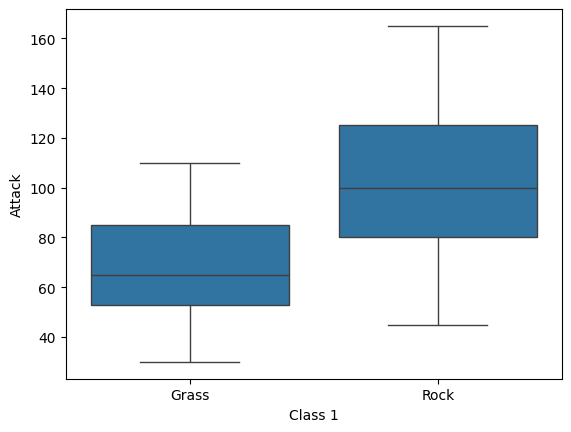

In [26]:
sns.boxplot(x='Class 1', y='Attack', data=grass_and_rock)

Из графика видно, что средняя сила атаки у покемонов класса Rock выше.



Выдвинем H0 - покемоны класса Rock и Grass имеют равную силу атаки.
Попробуем принять ее или опровергнуть:

In [14]:
Grass = grass_and_rock[grass_and_rock['Class 1'] == 'Grass']
Rock = grass_and_rock[grass_and_rock['Class 1'] == 'Rock']

In [21]:
res = ttest_ind(Grass['Attack'], Rock['Attack'])
a = 0.05

if res.pvalue < a:
    print('Н0 не верна, сила атаки у классов разная')
else:
    print('Н0 верна')

Н0 не верна, сила атаки у классов разная


In [22]:
a = int(Grass['Attack'].mean())
b = int(Rock['Attack'].mean())
print(a)
print(b)

68
103


Таким образом мы подтвердили графически представленные выводы о том, что средняя сила атаки у класса Rock выше.

<div class="alert alert-info">
<b>Задание № 2:</b>
    
Профессор Оук уже долго не может спать по ночам, ведь его волнует вопрос, а правда ли, что покемоны в классе `Water` в среднем быстрее, чем покемоны в классе `Normal`.
    
    
Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
Примечание: если есть покемоны, которые относятся к обоим классам, выбросьте их;
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.
</div>

In [27]:
water_and_normal = pokemon.loc[((pokemon['Class 1'] == 'Water') | (pokemon['Class 1'] == 'Normal')) & (pokemon['Class 2'].isna())]
water_and_normal.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
9,10,Squirtle,Water,NaN,44,48,65,50,64,43,False
10,11,Wartortle,Water,NaN,59,63,80,65,80,58,False
11,12,Blastoise,Water,NaN,79,83,100,85,105,78,False
12,13,Mega Blastoise,Water,NaN,79,103,120,135,115,78,False
24,25,Rattata,Normal,NaN,30,56,35,25,35,72,False


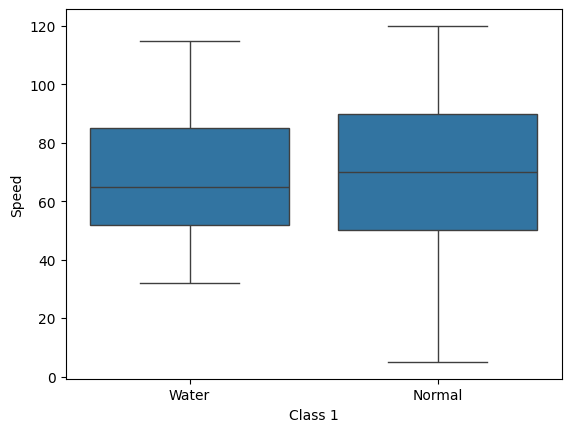

In [29]:
sns.boxplot(x='Class 1', y='Speed', data=water_and_normal);

Выдвинем H0 - покемоны класса Water и Normal имеют разную среднюю скорость. Попробуем принять ее или опровергнуть:

In [30]:
Water = water_and_normal[water_and_normal['Class 1'] == 'Water']
Normal = water_and_normal[water_and_normal['Class 1'] == 'Normal']

In [31]:
res = stats.ttest_ind(Water['Speed'], Normal['Speed'], equal_var=False)
a = 0.05

if (res.pvalue < a):
    print('Н0 не верна, средняя скорость классов одинаковая')
else:
    print('Н0 верна, средняя скорость классов разная')

Н0 верна, средняя скорость классов разная


In [32]:
a = int(Water['Speed'].mean())
b = int(Normal['Speed'].mean())
print(a)
print(b)

67
69


Покемоны в классе Normal в среднем быстрее покемонов в классе Water

<div class="alert alert-info">
<b>Задание № 3:</b>
    
Профессор Оук тот еще безумец. Он изобрёл сыворотку, способную ускорить покемона. Однако мы усомнились в эффективности его вакцины. Професоор дал эту сыворотку следующим покемонам: смотри массив `treathed_pokemon`. Проверьте, работает ли вообще его сыворотка, убедите всех в своём выводе статистически.
    
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.

</div>

In [33]:
# Покемоны, которые принимали сыворотку увеличения скорости
treathed_pokemon = ['Mega Beedrill', 'Mega Alakazam',
                    'Deoxys Normal Forme', 'Mega Lopunny']

In [36]:
treathed_pokemons = pokemon[(pokemon['Name'].isin(treathed_pokemon))].filter(['Speed'])
threated_speed = treathed_pokemons.mean()[0]
treathed_pokemons.head()

,Speed
19,145
71,150
428,150
476,135


In [37]:
other_pokemons = pokemon[(pokemon['Name'].isin(treathed_pokemon)==False)].filter(['Speed'])
other_speed = other_pokemons.mean()[0]
other_pokemons.head()

,Speed
0,45
1,60
2,80
3,80
4,65


Выдвинем H0 - скорость покемонов с сывороткой и без одинаковая.
Попробуем принять ее или опровергнуть:

In [38]:
res = stats.ttest_ind(treathed_pokemons, other_pokemons, equal_var=False)
a = 0.05

if (res.pvalue < a):
    print('Н0 не верна, скорость покемонов с сывороткой выше')
else:
    print('Н0 верна, скорость покемонов с сывороткой и без одинаковая')

Н0 не верна, скорость покемонов с сывороткой выше


In [39]:
df_treathed_pokemon = pokemon[pokemon['Name'].isin(treathed_pokemon)]
df_treathed_pokemon

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,False
71,72,Mega Alakazam,Psychic,NaN,55,50,65,175,95,150,False
428,429,Deoxys Normal Forme,Psychic,NaN,50,150,50,150,50,150,True
476,477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,False


In [42]:
drop_df_treathed_pokemon = pd.concat([pokemon, df_treathed_pokemon]).drop_duplicates(keep=False)

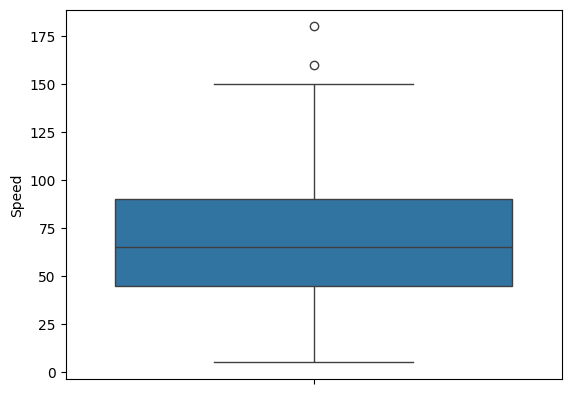

In [43]:
sns.boxplot(y='Speed', data=drop_df_treathed_pokemon);

Видим, что показатели скорости покемонов из списка treated_pokemons существенно выше средних значений.

<div class="alert alert-info">
<b>Задание № 4:</b>
    
Профессор Оук всегда любил истории про легендарных покемонов. Однако профессор не очень уверен, что они лучше остальных покемонов. Оук предложил разобраться в этом нам. Проверьте, действительно ли сумма характеристик `HP`,`Attack`,`Defense` у легендарных покемонов выше, чем у других покемонов?

А произведение этих же параметров?

Найдите ответы на эти вопросы и убедите всех в своём выводе статистически.
   

Вы можете предположить, что распределение сум и произведений этих параметров является нормальным для всех классов покемонов.

</div>

In [45]:
df_pokemon_true = pokemon[(pokemon['Legendary'] == True)][['HP','Attack','Defense']]
df_pokemon_true['Sum'] = df_pokemon_true['HP'] + df_pokemon_true['Attack'] + df_pokemon_true['Defense']
df_pokemon_true['Prod'] = df_pokemon_true['HP'] * df_pokemon_true['Attack'] * df_pokemon_true['Defense']
df_pokemon_true.head()

,HP,Attack,Defense,Sum,Prod
156,90,85,100,275,765000
157,90,90,85,265,688500
158,90,100,90,280,810000
162,106,110,90,306,1049400
163,106,190,100,396,2014000


In [46]:
df_pokemon_false = pokemon[(pokemon['Legendary'] == False)][['HP','Attack','Defense']]
df_pokemon_false['Sum'] = df_pokemon_false['HP'] + df_pokemon_false['Attack'] + df_pokemon_false['Defense']
df_pokemon_false['Prod'] = df_pokemon_false['HP'] * df_pokemon_false['Attack'] * df_pokemon_false['Defense']
df_pokemon_false.head()

,HP,Attack,Defense,Sum,Prod
0,45,49,49,143,108045
1,60,62,63,185,234360
2,80,82,83,245,544480
3,80,100,123,303,984000
4,39,52,43,134,87204


Выдвинем H0 - средняя сумма показателей у легендарных и обычных покемонов одинаковая. Попробуем принять ее или опровергнуть:

In [47]:
res = stats.ttest_ind(df_pokemon_true['Sum'], df_pokemon_false['Sum'], equal_var=False)
a = 0.05

if (res.pvalue < a):
    print('Н0 не верна, средняя сумма показателей у легендарных и обычных покемонов разная')
else:
    print('Н0 верна, средняя сумма показателей у легендарных и обычных покемонов одинаковая')

Н0 не верна, средняя сумма показателей у легендарных и обычных покемонов разная


In [48]:
a = int(df_pokemon_true['Sum'].mean())
b = int(df_pokemon_false['Sum'].mean())
print(a)
print(b)

309
214


Средняя сумма показателей у легендарных покемонов больше, чем у обычных.

Выдвинем H0 - среднее произведение показателей у легендарных и обычных покемонов одинаковое. Попробуем принять ее или опровергнуть:

In [49]:
res = stats.ttest_ind(df_pokemon_true['Prod'], df_pokemon_false['Prod'], equal_var=False)
a = 0.05

if (res.pvalue < a):
    print('Н0 не верна, среднее произведение показателей у легендарных и обычных покемонов разное')
else:
    print('Н0 верна, среднее произведение показателей у легендарных и обычных покемонов одинаковое')

Н0 не верна, среднее произведение показателей у легендарных и обычных покемонов разное


In [50]:
a = int(df_pokemon_true['Prod'].mean())
b = int(df_pokemon_false['Prod'].mean())
print(a)
print(b)

1085941
425041


Среднее произведение показателей у легендарных покемонов больше, чем у обычных.

<div class="alert alert-info">
<b>Задание № 5:</b>
    
Профессор Оук частенько наблюдает за боями покемонов. После очередных таких боёв Оук выделил четыре класса `best_defence_class`, которые на его взгляд одинаковы по "силе обычной защиты" `Defense`.

Проверьте, действительно ли эти классы покемонов не отличаются по уровню защиты статистически значимо? Всё та же статистика вам в помощь!
   

Вы можете предположить, что распределение параметров защитных характеристик является нормальным для всех классов покемонов.

</div>

In [51]:
best_defence_class = ['Rock', 'Ground', 'Steel', 'Ice']
best_defence_class

['Rock', 'Ground', 'Steel', 'Ice']

In [52]:
best_defence = pokemon[(pokemon['Class 2'].isin(best_defence_class)) | (pokemon['Class 1'].isin(best_defence_class))][['Class 1','Class 2','Defense']]
best_defence.head()

,Class 1,Class 2,Defense
32,Ground,NaN,85
33,Ground,NaN,110
36,Poison,Ground,87
39,Poison,Ground,77
55,Ground,NaN,25


In [55]:
best_defence['Class'] = np.where(best_defence['Class 1'].isin(best_defence_class), best_defence['Class 1'], best_defence['Class 2'])
best_defence.head()

,Class 1,Class 2,Defense,Class
32,Ground,NaN,85,Ground
33,Ground,NaN,110,Ground
36,Poison,Ground,87,Ground
39,Poison,Ground,77,Ground
55,Ground,NaN,25,Ground


Выдвинем H0 - классы одинаковы по силе обычной защиты. Попробуем принять ее или опровергнуть:

<Axes: xlabel='Class', ylabel='Defense'>

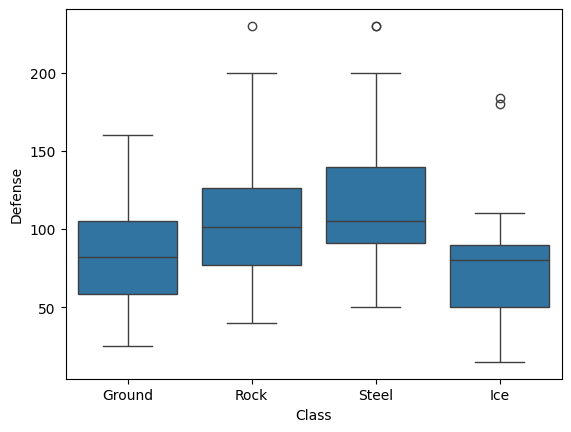

In [56]:
sns.boxplot(x="Class", y="Defense", data=best_defence)

In [57]:
f, p = stats.f_oneway(best_defence[best_defence['Class'] == 'Rock']['Defense'], best_defence[best_defence['Class'] == 'Ground']['Defense'], best_defence[best_defence['Class'] == 'Steel']['Defense'], best_defence[best_defence['Class'] == 'Ice']['Defense'])  # дисперсионный анализ (ДА) в python
a = 0.05

if p < a:
    print('Н0 не верна, классы различаются по силе защиты')
else:
    print('H0 верна, классы не различаются по силе защиты')

Н0 не верна, классы различаются по силе защиты


# **Примечание:**

Домашнее задание сдается ссылкой [Google Colab](https://colab.research.google.com/). Мы не сможем проверить его или помочь, если вы пришлете:

*   файлы;
*   архивы;
*   скриншоты кода.

Все обсуждения и консультации по выполнению домашнего задания ведутся только на соответствующем канале в Discord.

**Как правильно задавать вопросы аспирантам, преподавателям и коллегам:**

Прежде чем задать вопрос, попробуйте найти ответ в интернете. Навык самостоятельного поиска информации — один из важнейших. Каждый практикующий специалист любого уровня делает это ежедневно.

Сформулируйте вопрос по алгоритму:

1.   Что я делаю?
2.   Какого результата я ожидаю?
3.   Как фактический результат отличается от ожидаемого?
4.   Что я уже попробовал сделать, чтобы исправить проблему?

По возможности прикрепите к вопросу скриншоты либо ссылки на код. Не выкладывайте все решение, оставляйте только проблемный и воспроизводимый участок кода.